[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rosmy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


First 5 Rows
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Shape: (50000, 2)

Missing Values
review       0
sentiment    0
dtype: int64

Sentiment Distribution
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Cleaning reviews...
Cleaning Completed!

Training Shape: (40000, 5000)
Testing Shape: (10000, 5000)

Model Trained Successfully!

Model Accuracy: 89.14%

Confusion Matrix
[[4345  616]
 [ 470 4569]]


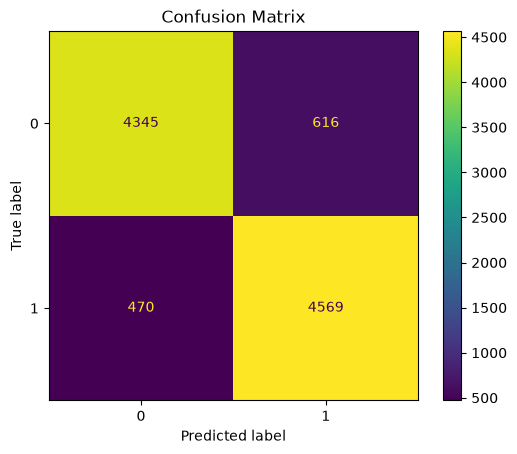


Classification Report

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Custom Review Predictions

---------------------------------------------
Review:
This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive 😊
---------------------------------------------
Review:
Worst movie ever. Complete waste of time.
Prediction: Negative 😞
---------------------------------------------
Review:
The acting was good but the story was boring.
Prediction: Negative 😞
---------------------------------------------
Review:
Fantastic direction and brilliant performances.
Prediction: Positive 😊
---------------------------------------------
Review:
I will never recommend this movie to anyone.
Prediction: 

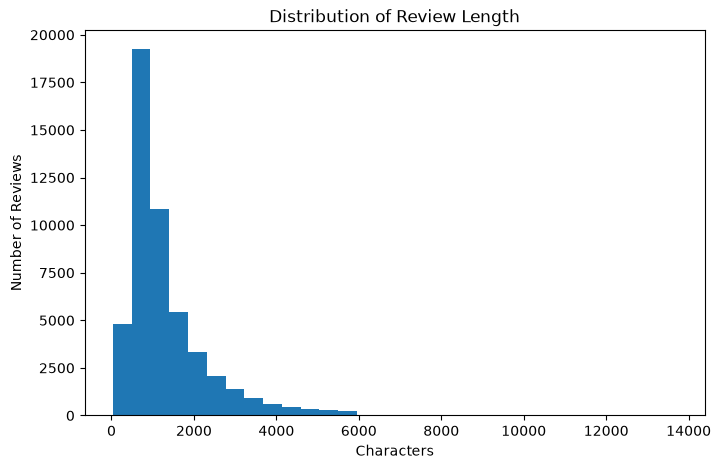


Task Completed Successfully!


In [1]:
# ==========================================================
# TASK 2 - SENTIMENT ANALYSIS USING TF-IDF & LOGISTIC REGRESSION
# Author: Jomin S George
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Download stopwords
nltk.download('stopwords')

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("dataset/IMDB Dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nSentiment Distribution")
print(df["sentiment"].value_counts())

# ==========================================================
# Convert Labels
# ==========================================================

df["sentiment"] = df["sentiment"].map({
    "negative":0,
    "positive":1
})

# ==========================================================
# Text Cleaning Function
# ==========================================================

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

print("\nCleaning reviews...")

df["clean_review"] = df["review"].apply(clean_text)

print("Cleaning Completed!")

# ==========================================================
# TF-IDF Vectorization
# ==========================================================

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment"]

# ==========================================================
# Split Dataset
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==========================================================
# Train Logistic Regression Model
# ==========================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("\nModel Trained Successfully!")

# ==========================================================
# Prediction
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# Accuracy
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy: {:.2f}%".format(accuracy*100))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ==========================================================
# Predict Custom Reviews
# ==========================================================

reviews = [

    "This movie was absolutely amazing and I loved every minute of it.",

    "Worst movie ever. Complete waste of time.",

    "The acting was good but the story was boring.",

    "Fantastic direction and brilliant performances.",

    "I will never recommend this movie to anyone."

]

print("\nCustom Review Predictions\n")

for review in reviews:

    cleaned = clean_text(review)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)

    if prediction[0] == 1:

        sentiment = "Positive 😊"

    else:

        sentiment = "Negative 😞"

    print("---------------------------------------------")
    print("Review:")
    print(review)
    print("Prediction:", sentiment)

# ==========================================================
# Sample Review Length Distribution
# ==========================================================

df["Review Length"] = df["review"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(df["Review Length"], bins=30)

plt.title("Distribution of Review Length")

plt.xlabel("Characters")

plt.ylabel("Number of Reviews")

plt.show()

print("\nTask Completed Successfully!")